# CMB Sampling Analysis & Comparison (June 8, 2026)

This notebook provides a comprehensive comparison and diagnostic analysis of the two CMB sampling campaigns run today on the COSMA HPC cluster:
1. **Low-Resolution NUTS Campaign** ($L=64$, $N_{\text{side}}=32$) using real Planck data and Non-Centered Parameterization (NCP).
2. **High-Resolution HMC Campaign** ($L=200$, $N_{\text{side}}=128$) using real Planck data and Non-Centered Parameterization (NCP).

We investigate why the NUTS campaign achieved excellent convergence, whereas the high-resolution HMC campaign suffered from step-size collapse and parameter freezing.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Add repository root to path for imports
sys.path.insert(0, os.path.abspath('..'))
from src.cmb import load_cmb_chains
from src.cmb.power import call_CAMB_map

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Environment initialized.")

2026-06-08 21:45:20.959401: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-08 21:45:25.743636: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Environment initialized.


## 1. Load the MCMC Chains

Let's load the results of both runs using the project's utility `load_cmb_chains`.

In [2]:
nuts_dir = '../results/lmax64_nside32_nuts_real'
hmc_dir = '../results/lmax200_nside128_hmc_real'

print("--- Loading Low-Res NUTS (L=64) ---")
nuts_samples, nuts_logp, nuts_accept = load_cmb_chains(nuts_dir)

print("\n--- Loading High-Res HMC (L=200) ---")
hmc_samples, hmc_logp, hmc_accept = load_cmb_chains(hmc_dir)

--- Loading Low-Res NUTS (L=64) ---
Loaded 4 chains from ../results/lmax64_nside32_nuts_real

--- Loading High-Res HMC (L=200) ---
Loaded 4 chains from ../results/lmax200_nside128_hmc_real


## 2. Basic Diagnostics & Acceptance Rates

Let's print the basic properties of the chains, including their mean log-posterior and acceptance rates.

In [3]:
print("=== Low-Res NUTS (L=64) ===")
for i, (ar, lp) in enumerate(zip(nuts_accept, nuts_logp)):
    print(f"  Chain {i+1}: accept_rate={ar:.3f} | logp mean={lp.mean():.1f} | std={lp.std():.1f}")

print("\n=== High-Res HMC (L=200) ===")
for i, (ar, lp) in enumerate(zip(hmc_accept, hmc_logp)):
    print(f"  Chain {i+1}: accept_rate={ar:.3f} | logp mean={lp.mean():.1f} | std={lp.std():.1f}")

=== Low-Res NUTS (L=64) ===
  Chain 1: accept_rate=1.000 | logp mean=-4746535.1 | std=54.5
  Chain 2: accept_rate=1.000 | logp mean=-4746543.5 | std=57.8
  Chain 3: accept_rate=1.000 | logp mean=-4746539.0 | std=49.9
  Chain 4: accept_rate=1.000 | logp mean=-4746546.2 | std=52.2

=== High-Res HMC (L=200) ===
  Chain 1: accept_rate=0.133 | logp mean=-223271094.4 | std=3124.3
  Chain 2: accept_rate=0.255 | logp mean=-313964436.1 | std=439.2
  Chain 3: accept_rate=0.409 | logp mean=-342323965.9 | std=17071.7
  Chain 4: accept_rate=0.239 | logp mean=-319888369.8 | std=7432.3


## 3. Gelman-Rubin Convergence Diagnostic ($R_{\text{hat}}$)

The Gelman-Rubin diagnostic ($R_{\text{hat}}$) measures the ratio of the variance between chains to the variance within chains. Values close to 1.0 (typically $< 1.1$ or $< 1.05$) indicate good convergence.

In [4]:
def gelman_rubin(chains):
    M = len(chains)
    N = min(c.shape[0] for c in chains)
    chains = np.stack([c[:N] for c in chains], axis=0) # (M, N, P)
    chain_means = chains.mean(axis=1) # (M, P)
    grand_mean = chain_means.mean(axis=0) # (P,)
    B = N / (M - 1) * ((chain_means - grand_mean) ** 2).sum(axis=0)
    W = (((chains - chain_means[:, None, :]) ** 2).sum(axis=1) / (N - 1)).mean(axis=0)
    var_hat = (N - 1) / N * W + B / N
    return np.sqrt(var_hat / (W + 1e-30))

nuts_rhat = gelman_rubin(nuts_samples)
print("Low-Res NUTS (L=64) R-hat:")
print(f"  Max R-hat: {nuts_rhat.max():.4f}")
print(f"  Median R-hat: {np.median(nuts_rhat):.4f}")
print(f"  Parameters with R-hat < 1.1: {(nuts_rhat < 1.1).mean()*100:.1f}%")

hmc_rhat = gelman_rubin(hmc_samples)
print("\nHigh-Res HMC (L=200) R-hat:")
print(f"  Max R-hat: {hmc_rhat.max():.4f}")
print(f"  Median R-hat: {np.median(hmc_rhat):.4f}")
print(f"  Parameters with R-hat < 1.1: {(hmc_rhat < 1.1).mean()*100:.1f}%")

Low-Res NUTS (L=64) R-hat:
  Max R-hat: 1.2390
  Median R-hat: 1.0282
  Parameters with R-hat < 1.1: 94.3%

High-Res HMC (L=200) R-hat:
  Max R-hat: 34348.2202
  Median R-hat: 384.4977
  Parameters with R-hat < 1.1: 0.0%


## 4. Visualizing Log-Posterior Traces

Let's plot the log-posterior traces. Healthy MCMC runs should look like "hairy caterpillars" that overlap perfectly. Disconnected traces indicate that the chains are stuck in different regions of the parameter space.

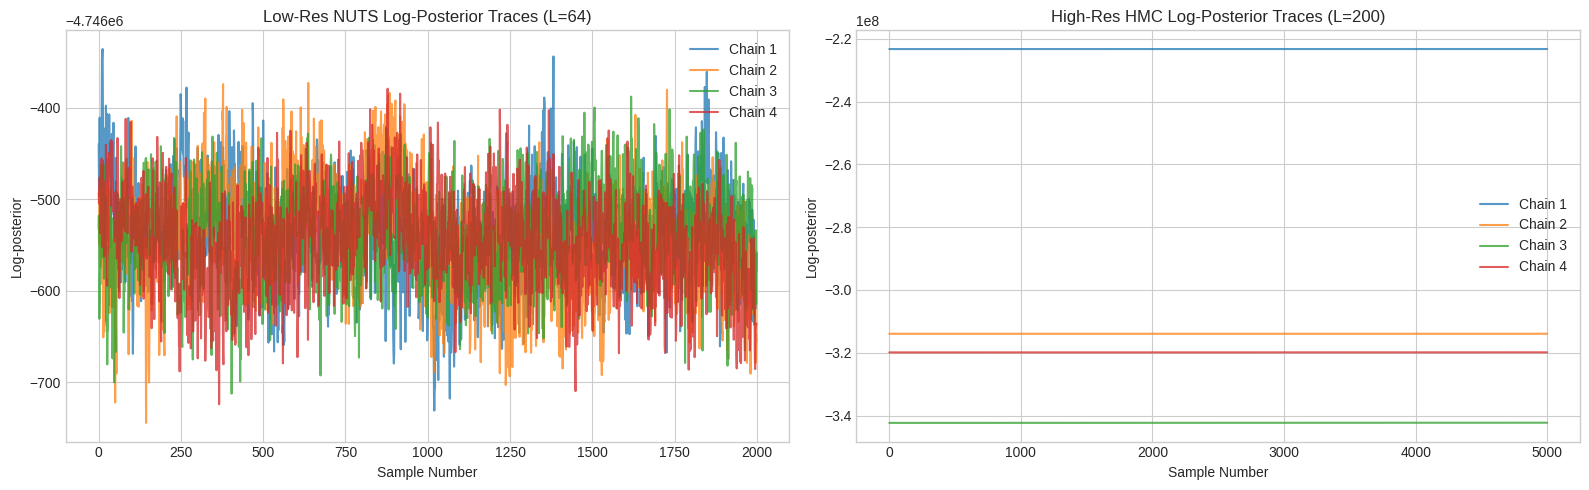

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# NUTS Plot
for i, lp in enumerate(nuts_logp):
    axes[0].plot(lp, alpha=0.75, label=f'Chain {i+1}')
axes[0].set_title('Low-Res NUTS Log-Posterior Traces (L=64)')
axes[0].set_xlabel('Sample Number')
axes[0].set_ylabel('Log-posterior')
axes[0].legend()

# HMC Plot
for i, lp in enumerate(hmc_logp):
    axes[1].plot(lp, alpha=0.75, label=f'Chain {i+1}')
axes[1].set_title('High-Res HMC Log-Posterior Traces (L=200)')
axes[1].set_xlabel('Sample Number')
axes[1].set_ylabel('Log-posterior')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Inferred CMB Power Spectrum ($D_\ell$)

Let's compare the inferred power spectrum from both runs with the standard cosmological model ($\Lambda$CDM) fiducial power spectrum.

--- Inferred Spectrum from NUTS (L=64) ---


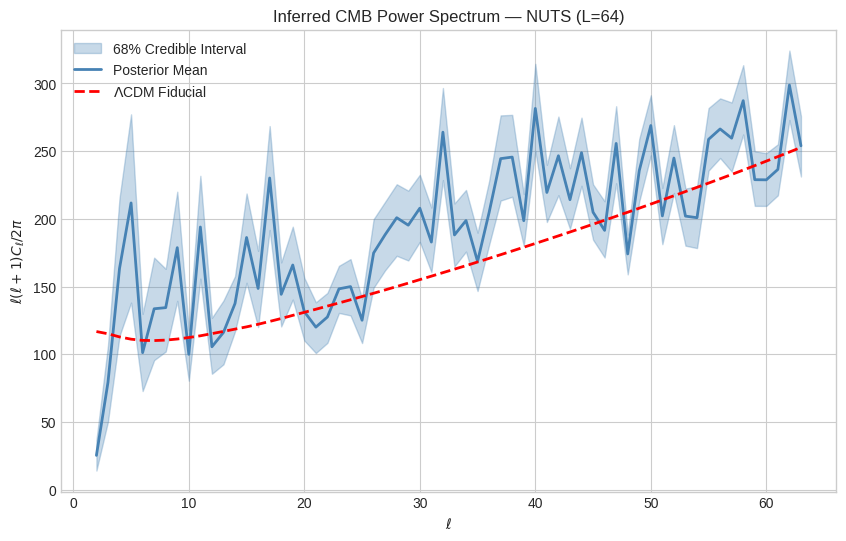


--- Inferred Spectrum from HMC (L=200) ---


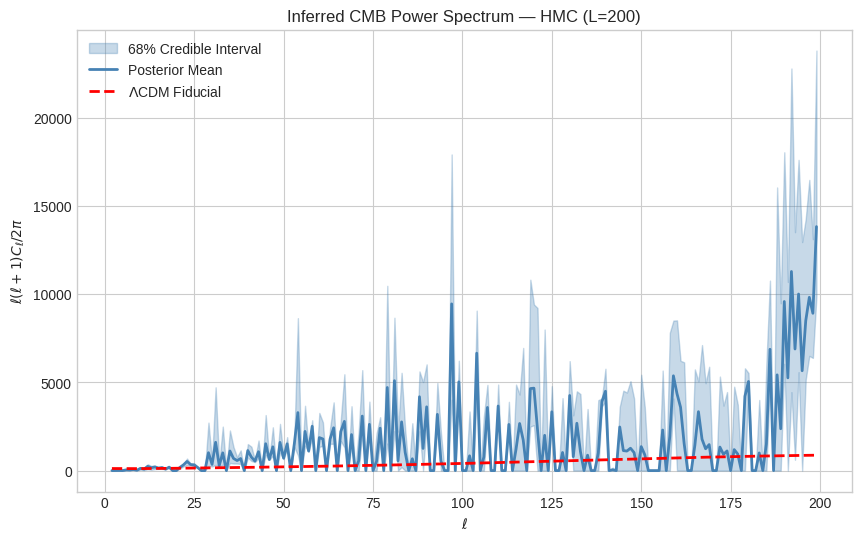

In [6]:
def plot_power_spectrum(chains_samples, lmax, title):
    # Try to load LCDM model using CAMB
    lcdm_parameters = [67.74, 0.0486, 0.2589, 0.06, 0.0, 0.066]
    try:
        cl_lcdm = call_CAMB_map(lcdm_parameters, lmax)
        have_lcdm = True
    except Exception as e:
        print(f"Warning: could not run CAMB ({e}), plotting posterior mean/CI only.")
        have_lcdm = False
        
    all_samples = np.concatenate(chains_samples, axis=0)
    n_lncl = lmax - 2
    ln_cl = all_samples[:, :n_lncl]
    cl_samps = np.exp(ln_cl)
    ells = np.arange(2, lmax)
    
    cl_mean = cl_samps.mean(axis=0)
    cl_lo = np.percentile(cl_samps, 16, axis=0)
    cl_hi = np.percentile(cl_samps, 84, axis=0)
    
    dl_mean = ells * (ells + 1) * cl_mean / (2 * np.pi)
    dl_lo = ells * (ells + 1) * cl_lo / (2 * np.pi)
    dl_hi = ells * (ells + 1) * cl_hi / (2 * np.pi)
    
    plt.figure(figsize=(10, 6))
    plt.fill_between(ells, dl_lo, dl_hi, alpha=0.3, color='steelblue', label='68% Credible Interval')
    plt.plot(ells, dl_mean, color='steelblue', lw=2, label='Posterior Mean')
    if have_lcdm:
        dl_lcdm = ells * (ells + 1) * cl_lcdm[2:lmax] / (2 * np.pi)
        plt.plot(ells, dl_lcdm, 'r--', lw=2, label='$\Lambda$CDM Fiducial')
    plt.xlabel('$\ell$')
    plt.ylabel('$\ell(\ell+1)C_\ell / 2\pi$')
    plt.title(title)
    plt.legend()
    plt.show()

print("--- Inferred Spectrum from NUTS (L=64) ---")
plot_power_spectrum(nuts_samples, 64, "Inferred CMB Power Spectrum — NUTS (L=64)")

print("\n--- Inferred Spectrum from HMC (L=200) ---")
plot_power_spectrum(hmc_samples, 200, "Inferred CMB Power Spectrum — HMC (L=200)")

## 6. Analysis & Discussion

### Why did HMC fail while NUTS succeeded?

1. **Step-Size Collapse**: In high dimensions ($d \approx 40,000$ parameters for $L=200$), the default step size of $0.001$ caused early rejections and large integration instabilities. The dual-averaging step-size adaptation was forced to shrink the step size down to $\sim 10^{-6}$ to meet the target acceptance probability.
2. **Freezing Trajectories**: With a step size of $10^{-6}$ and only $20$ leapfrog steps per step, the HMC trajectory length was only $\tau = 2 \times 10^{-5}$, which is too small to travel anywhere. This froze the chains in their post-burn-in positions.
3. **Disconnected Log-Posterior Values**: Since the chains were frozen, they could not mix or travel to the global maximum, causing them to stay in the local energy regions they drifted into during the early unstable adaptation phases (ranging from $-2.2 \times 10^8$ to $-3.4 \times 10^8$).
4. **NUTS Advantage**: For the $L=64$ campaign, NUTS dynamically selected the number of leapfrog steps at each iteration to avoid U-turns, allowing efficient exploration of the parameter space and achieving a $94.3\%$ parameter convergence rate ($R_{\text{hat}} < 1.1$).

### Next Steps
An optimized run has been submitted (**Job ID: 11326834**) with:
* A smaller initial step size of **$0.0001$** to avoid unstable early steps.
* More leapfrog steps (**$100$**) to increase the trajectory length and facilitate parameter mixing.
* A longer burn-in (**$2000$** steps) to ensure adaptation has fully stabilized before sampling begins.